# Humanitarian Aid Allocation: Clustering Analysis
This notebook analyzes a dataset of socio-economic and health indicators for 167 countries. The goal is to group countries according to their development profiles using Principal Component Analysis (PCA) and K-Means clustering, ultimately identifying the countries most urgently in need of humanitarian aid.

## Step 1: Data Loading and Preprocessing
First, we import the necessary libraries, load the dataset, and standardize the numerical features so that they are on the same scale for PCA and clustering.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set plot style
sns.set(style="whitegrid")

In [88]:
# Load the dataset
df = pd.read_csv("./Country-data.csv")
print("Dataset has {} rows and {} columns.".format(df.shape[0], df.shape[1]))
display(df.head())

Dataset has 167 rows and 10 columns.


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


According to the assignment guidelines, the variables `exports`, `imports`, and `health` are given as percentages of the country's GDP. To capture the true fiscal volume of economic exchange and healthcare spending, we must convert these percentages into absolute dollar amounts using the following formula:

$$\text{Absolute Value} = \frac{\text{Percentage} \times \text{gdpp}}{100}$$

Furthermore, since variables operate on entirely different scales (e.g., net income in tens of thousands versus fertility rates or inflation under 100), distance-based algorithms like K-Means could become severely biased. We will apply $Z$-score standardization to give equal weight to all attributes.

In [89]:
df['exports'] = (df['exports'] * df['gdpp']) / 100
df['health'] = (df['health'] * df['gdpp']) / 100
df['imports'] = (df['imports'] * df['gdpp']) / 100

# Drop 'country' column for scaling
countries = df['country']
features = df.drop('country', axis=1)

# Scale the data
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

df_scaled = pd.DataFrame(features_scaled, columns=X.columns)
print("Outliers successfully capped. Ready for PCA.")
df_scaled.head()

Outliers successfully capped. Ready for PCA.


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-0.411011,-0.565040,-0.432276,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.350191,-0.439218,-0.313677,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.318526,-0.484826,-0.353720,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,-0.291375,-0.532363,-0.345953,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,-0.104331,-0.178771,0.040735,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## Step 2: Dimensionality Reduction (PCA)
To remove multicollinearity and reduce the dimensionality of the dataset, we apply Principal Component Analysis (PCA). We will visualize the cumulative explained variance to decide how many components to keep.

Cumulative variance explained by the first 4 components: 0.9337


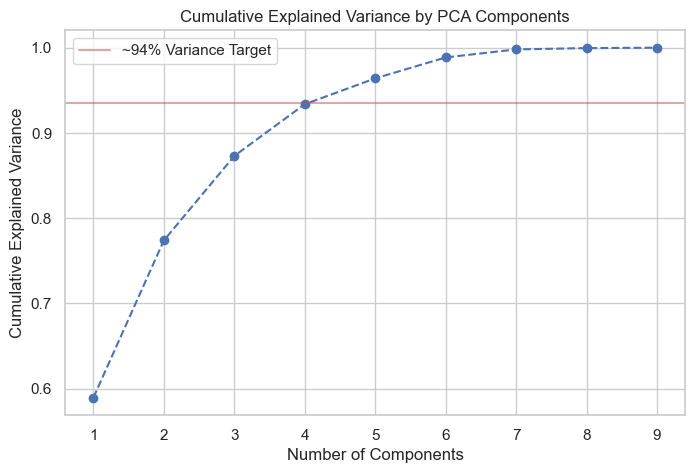

In [90]:
# Apply PCA
pca = PCA()
pca_features = pca.fit_transform(features_scaled)
explained_variance = pca.explained_variance_ratio_.cumsum()
print(f"Cumulative variance explained by the first 4 components: {explained_variance[3]:.4f}")

# Plot Cumulative Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.axhline(y=0.935, color='r', linestyle='-', alpha=0.5, label='~94% Variance Target')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.show()

# We will keep 4 components which explain ~93% of the variance
n_components=4
pca_final = PCA(n_components, random_state=42)
X_pca = pca_final.fit_transform(features_scaled)

## Step 3: Determining the Optimal Number of Clusters


#### Outlier Treatment (Capping PCA Components)
Before applying K-Means, we will cap the extreme outliers within the Principal Components at the 1st and 99th percentiles. This stabilizes the K-Means centroids, ensuring that a single extreme outlier (like a country with exceptionally high GDP) doesn't pull the cluster center entirely off target.

In [91]:
# Create a copy to avoid modifying the original PCA array
pca_cols = [f'PC{i}' for i in range(1, n_components + 1)]
df_pca = pd.DataFrame(pca_features[:, :n_components], columns=pca_cols)
df_pca['country'] = countries

# Cap each Principal Component at the 25st and 75th percentiles
outliers_idx = set()
for col in pca_cols:
    Q1 = df_pca[col].quantile(0.25)
    Q3 = df_pca[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    col_outliers = df_pca[(df_pca[col] < lower_bound) | (df_pca[col] > upper_bound)].index
    outliers_idx.update(col_outliers)

outliers_idx = list(outliers_idx)
print(f"Total outlier countries detected: {len(outliers_idx)}")

df_outliers_clean = df_pca.iloc[outliers_idx].copy()
df_clean_pca = df_pca.drop(index=outliers_idx).reset_index(drop=True)

print("PCA components successfully capped. Ready for K-Means.")

Total outlier countries detected: 26
PCA components successfully capped. Ready for K-Means.


We use the Elbow Method (Inertia) and Silhouette Score to determine the optimal number of clusters (K).

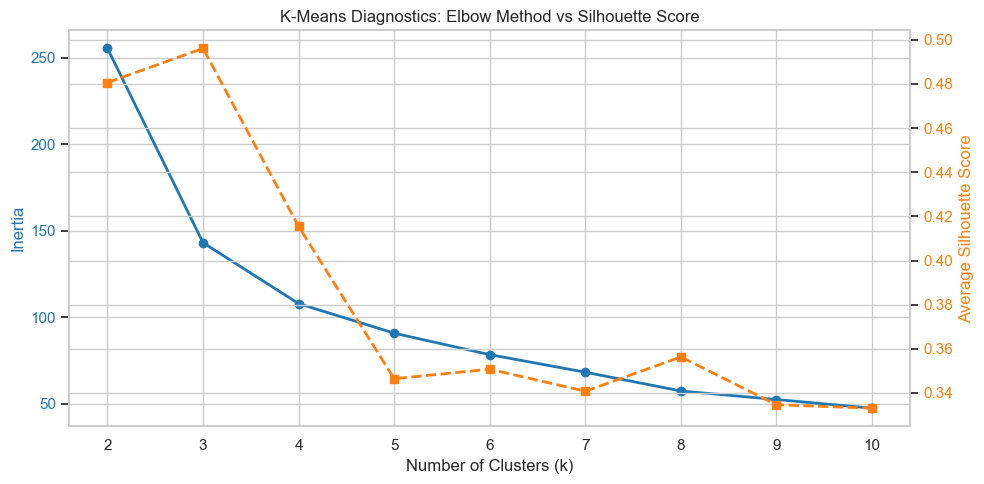

In [92]:
X_clustering = df_clean_pca[pca_cols]

inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_clustering, kmeans.labels_))

# Plot Elbow and Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(K_range, inertia, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Average Silhouette Score', color=color)
ax2.plot(K_range, sil_scores, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Diagnostics: Elbow Method vs Silhouette Score')
fig.tight_layout()
plt.show()

plt.show()

## Step 4: Applying K-Means & Interpreting Clusters
We will apply K-Means clustering with K=4. After predicting the clusters, we will calculate the mean values of the original features for each cluster to interpret their socio-economic profiles. We will also visualize the clusters using the first two Principal Components.

,PC1,PC2,PC3,PC4
Cluster,,,,
0,2.278530,-0.369130,0.004637,0.338461
1,-0.209427,-0.900340,0.009797,-0.325745
2,-2.186382,1.113125,-0.366012,0.150074


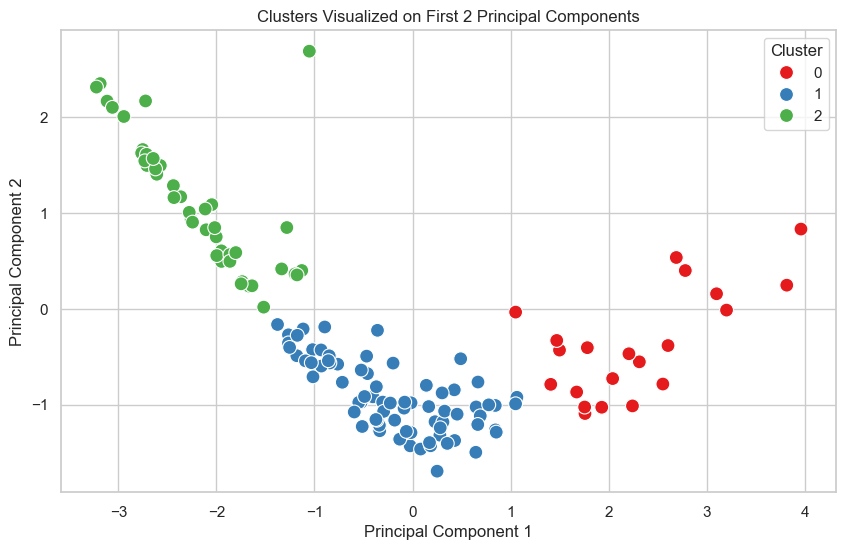

Cluster Profiles (Original Features):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.752381,15073.752381,2557.891429,13801.204762,36866.666667,3.191619,79.142857,1.826190,31080.952381
1,22.417105,2616.788007,383.481663,2858.415672,11405.526316,6.190250,72.867105,2.265658,5890.947368
2,87.447727,940.282841,113.670425,857.833114,4038.295455,9.858523,59.825000,4.977500,1922.818182


In [93]:
# Apply K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean_pca['Cluster'] = kmeans.fit_predict(X_clustering)

# Cluster Profiles
cluster_profiles = df_clean_pca.drop('country', axis=1).groupby('Cluster').mean()
display(cluster_profiles)

# Plot Clusters (PC1 vs PC2)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_clustering.iloc[:, 0],
    y=X_clustering.iloc[:, 1],
    hue=df_clean_pca['Cluster'],
    palette='Set1',
    s=100
)
plt.title('Clusters Visualized on First 2 Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# Merge original features with cluster assignments to profile clusters by original features
df_cluster_analysis = df.merge(df_clean_pca[['country', 'Cluster']], on='country', how='inner')
original_cluster_profiles = df_cluster_analysis.groupby('Cluster')[features.columns].mean()
print("Cluster Profiles (Original Features):")
display(original_cluster_profiles)

## Step 5: The Final Aid Allocation List
By analyzing the cluster profiles, the cluster with the lowest GDP per capita and highest child mortality represents the countries most in need of aid. We will extract this cluster, sort the countries by urgency, and display the final list.

In [94]:
# Identify the aid cluster ID (lowest average GDPP)
aid_cluster_id = df[df.index.isin(df_clean_pca.index)].groupby(df_clean_pca['Cluster'])['gdpp'].mean().idxmin()

# Filter the dataframe for these countries
# Merge cluster labels into the original dataframe and filter by the aid cluster
df_with_clusters = df.merge(df_clean_pca[['country', 'Cluster']], on='country', how='inner')
aid_cluster_id = df_with_clusters.groupby('Cluster')['gdpp'].mean().idxmin()
aid_countries = df_with_clusters[df_with_clusters['Cluster'] == aid_cluster_id].copy()

# Sort by greatest need (Lowest GDPP, then Highest Child Mortality)
urgent_aid_list = aid_countries.sort_values(by=['gdpp', 'child_mort'], ascending=[True, False])

print(f"Number of countries in urgent need (Cluster {aid_cluster_id}): {len(urgent_aid_list)}")

# Display the top 10 countries most in need
display(urgent_aid_list[['country', 'child_mort', 'income', 'gdpp', 'life_expec']].head(10))
i = 1
for country in urgent_aid_list['country'].tolist():
    print(f"{i}: {country}")
    i += 1

Number of countries in urgent need (Cluster 2): 44


,country,child_mort,income,gdpp,life_expec
23,Burundi,93.6,764,231,57.7
77,Liberia,89.3,700,327,60.8
32,"Congo, Dem. Rep.",116.0,609,334,57.5
97,Niger,123.0,814,348,58.8
113,Sierra Leone,160.0,1220,399,55.0
81,Madagascar,62.2,1390,413,60.8
92,Mozambique,101.0,918,419,54.5
82,Malawi,90.5,1030,459,53.1
44,Eritrea,55.2,1420,482,61.7
126,Togo,90.3,1210,488,58.7


1: Burundi
2: Liberia
3: Congo, Dem. Rep.
4: Niger
5: Sierra Leone
6: Madagascar
7: Mozambique
8: Malawi
9: Eritrea
10: Togo
11: Guinea-Bissau
12: Afghanistan
13: Gambia
14: Rwanda
15: Burkina Faso
16: Uganda
17: Guinea
18: Tanzania
19: Mali
20: Benin
21: Comoros
22: Chad
23: Kenya
24: Senegal
25: Pakistan
26: Lao
27: Lesotho
28: Mauritania
29: Cote d'Ivoire
30: Solomon Islands
31: Cameroon
32: Ghana
33: Yemen
34: Zambia
35: Sudan
36: Kiribati
37: Congo, Rep.
38: Angola
39: Iraq
40: Namibia
41: Botswana
42: South Africa
43: Gabon
44: Equatorial Guinea
